In [52]:
import pandas as pd
import os.path as op
import numpy as np
from os import listdir
import matplotlib.pyplot as plt

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
subFolders = [f[4:] for f in listdir(bids_folder) if f[0:3] == 'sub']

decod_dir = op.join(bids_folder, 'derivatives', 'decoded_pdfs.volume.svoxels.ses1-en_ses2-de.denoise.retroicor' )

In [14]:
parameter_names = ['mu','sd','amplitude','baseline']
dict_ses1 = {col_name: col_name + '_1' for col_name in parameter_names}
dict_ses2 = {col_name: col_name + '_2' for col_name in parameter_names}


### get visual cortex masks
apply the benson12 atlas to freesurfer surface subjects:

* set paths: SUBJECTS_DIR=/Volumes/mrenkeED/data/ds-stressrisk/derivatives/freesurfer
* then run transform: python -m neuropythy atlas --verbose sub-02


In [53]:
# check results from the atlas

import nibabel as nib
from nilearn import plotting, surface
import matplotlib.pyplot as plt

#example sub
subject_dir = '/Volumes/mrenkeED/data/ds-stressrisk/derivatives/freesurfer/sub-02'

lh_benson14_visual = subject_dir + '/surf/lh.benson14_varea.mgz'

lh_visual_img = nib.load(lh_benson14_visual)
lh_visual_data = lh_visual_img.get_fdata()

lh_visual_data[lh_visual_data != 1] = 0 # np.unique(lh_visual_data) = 0-12, 1 is V1, 2-12 otehr visual regions, 0 is everything outside visual cortex
lh_surf = subject_dir + '/surf/lh.pial'
lh_surface = surface.load_surf_mesh(lh_surf)

# Plot the data on the surface
plotting.view_surf(lh_surface, lh_visual_data).open_in_browser()

In [95]:
# copilot suggestion, doesn't work

sub = '02'
target_dir = op.join(bids_folder, 'derivatives', 'ips_masks', f'sub-{sub}')

hemi = 'lh'
subject_dir = '/Volumes/mrenkeED/data/ds-stressrisk/derivatives/freesurfer/sub-02'
hemi_benson14_visual = subject_dir + f'/surf/{hemi}.benson14_varea.mgz'
input_mgz = hemi_benson14_visual # op.join(target_dir, f'sub-{sub}_benson14-varea_space-fsnative_hemi-lh.v1.mgz')

output_nii = op.join(target_dir, f'sub-{sub}_benson14-varea_space-fsnative_hemi-lh.v1.nii')

# Load the .mgz file
mgz = nib.load(input_mgz)

# Save it as a .nii file
nib.save(mgz, output_nii)

print(f"Converted {input_mgz} to {output_nii}")

Converted /Volumes/mrenkeED/data/ds-stressrisk/derivatives/freesurfer/sub-02/surf/lh.benson14_varea.mgz to /Volumes/mrenkeED/data/ds-stressrisk/derivatives/ips_masks/sub-02/sub-02_benson14-varea_space-fsnative_hemi-lh.v1.nii


In [131]:
# extract V1 area from benson14_varea.mgz' & save to gii file 

sub = '61'
for hemi in  ['lh', 'rh']:
    hemi_benson14_visual = op.join(bids_folder, 'derivatives', 'freesurfer', f'sub-{sub}', 'surf', f'{hemi}.benson14_varea.mgz')
    hemi_visual_data = nib.load(hemi_benson14_visual).get_fdata()
    hemi_visual_data[hemi_visual_data != 1] = 0 

    im = nib.gifti.GiftiImage(darrays=[nib.gifti.GiftiDataArray(hemi_visual_data)])

    target_dir = op.join(bids_folder, 'derivatives', 'ips_masks', f'sub-{sub}')
    target_fn =  op.join(target_dir, f'sub-{sub}_benson14-varea_space-fsnative_hemi-{hemi}.v1.gii')
                        
    nib.save(im, target_fn)
    print(f'saved {target_fn}')

saved /Volumes/mrenkeED/data/ds-stressrisk/derivatives/ips_masks/sub-61/sub-61_benson14-varea_space-fsnative_hemi-lh.v1.gii
saved /Volumes/mrenkeED/data/ds-stressrisk/derivatives/ips_masks/sub-61/sub-61_benson14-varea_space-fsnative_hemi-rh.v1.gii


In [132]:
# transform to volume

from neuropythy.freesurfer import subject as fs_subject
from neuropythy.io import load, save
from neuropythy.mri import (is_image, is_image_spec, image_clear, to_image)

sub = '61'
target_subject = f'sub-{sub}'
ses_anat = 1
#fs_subjects_dir = op.join(bids_folder, 'derivatives', 'freesurfer')
fs_sub = fs_subject(op.join(bids_folder, 'derivatives', 'freesurfer', f'sub-{subject}'))

fsnative_fn_l = op.join(target_dir, f'sub-{sub}_benson14-varea_space-fsnative_hemi-lh.v1.gii')
fsnative_fn_r = op.join(target_dir, f'sub-{sub}_benson14-varea_space-fsnative_hemi-rh.v1.gii')
mask_data_l = surface.load_surf_data(fsnative_fn_l).astype(bool)
mask_data_r = surface.load_surf_data(fsnative_fn_r).astype(bool)

im_anat = load(op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{subject}',f'ses-{ses_anat}', 'anat', f'sub-{subject}_ses-{ses_anat}_desc-preproc_T1w.nii.gz'))
im_anat = to_image(image_clear(im_anat, fill=0.0), dtype=np.int)

print('Generating volume...')
new_im = fs_sub.cortex_to_image((mask_data_l, mask_data_r), # must give datarray for left and right (here: one is mask and other array with only 0s/False)
        im_anat,
        hemi=None,
        method='nearest',
        fill=0.0)

print('Exporting volume file: %s' % target_fn)
target_fn = op.join(target_dir, f'sub-{sub}_benson14-varea_space-T1w.v1.nii.gz')
save(target_fn, new_im)
print('surface_to_image complete!')

Generating volume...


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_19041/1569521024.py:19: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  im_anat = to_image(image_clear(im_anat, fill=0.0), dtype=np.int)
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/neuropythy/mri/images.py:112: FutureWarning: Image data has type int64, which may cause incompatibilities with other tools. This will error in NiBabel 5.0. This warning can be silenced by passing the dtype argument to Nifti1Image().
  img = cls(arr, aff, **kw)


ValueError: lh hemi/property size mismatch

In [133]:
sub = '61'
target_dir = op.join(bids_folder, 'derivatives', 'ips_masks', f'sub-{sub}')

fsnative_fn_r = op.join(target_dir, f'sub-{sub}_benson14-varea_space-fsnative_hemi-rh.v1.gii')
mask_data_r = surface.load_surf_data(fsnative_fn_r).astype(bool)

mask_data_r.shape
# 2 : 148035


(152053,)

In [134]:
ex_im= op.join(target_dir, f'sub-{sub}_desc-NPC_R_space-fsnative_hemi-rh.ips.gii')
ex_data = surface.load_surf_data(ex_im).astype(bool)

ex_data.shape

(151103,)

In [ ]:
# compare to fsaverage sizes 

from  nilearn.datasets import fetch_surf_fsaverage
 
fsaverage = fetch_surf_fsaverage('fsaverage')
#fsav_ex = nib.load(fsaverage.infl_right).
fsav_ex = surface.load_surf_data(fsaverage.infl_right)
fsav_ex[0].shape

ValueError: The surf_map does not have the same number of vertices as the mesh.

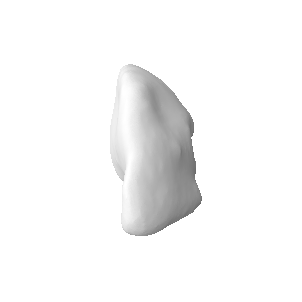

In [136]:
import nilearn.plotting as nplt

sub = '61'
view = 'posterior'
hemi = 'rh'
surf_mesh = op.join(bids_folder, 'derivatives', 'freesurfer', f'sub-{sub}', 'surf', f'{hemi}.inflated')
surf_map = op.join(bids_folder, 'derivatives', 'ips_masks', f'sub-{sub}', f'sub-{sub}_benson14-varea_space-fsnative_hemi-{hemi}.v1.gii')
#surf_map = op.join(bids_folder, 'derivatives', 'ips_masks', f'sub-{sub}', f'sub-{sub}_desc-NPC_R_space-fsnative_hemi-{hemi}.ips.gii')

#surf_map = nib.load(surf_map).agg_data() # does not make a difference!
#surf_map = surf_map.astype(bool)
bg_map = op.join(bids_folder, 'derivatives', 'freesurfer', f'sub-{sub}', 'surf', f'{hemi}.sulc')
nplt.plot_surf(surf_mesh= surf_mesh, surf_map= surf_map, # infl_right # pial_right
               view= view,colorbar=True,cmap='viridis',
               bg_map=bg_map, bg_on_data=True,darkness=0.5,
               )
# nplt.plot_surf_stat_map(surf_mesh=surf_mesh, stat_map=surf_map,cmap='viridis',view=view)
plt.show()

## current stand:

for sub 02 extracted v1 visualization works but not for NPC.gii mask
for sub 61 extracted v1 visualization works but not for NPC.gii mask the same after rsync freesurfer directory again

for both  `fs_sub.cortex_to_image` does not work

In [129]:
# transform to volume
# f'sub-{sub}_desc-NPC_R_space-fsnative_hemi-{hemi}.ips.gii'
from neuropythy.freesurfer import subject as fs_subject
from neuropythy.io import load, save
from neuropythy.mri import (is_image, is_image_spec, image_clear, to_image)

sub = '61'
target_subject = f'sub-{sub}'
ses_anat = 1
#fs_subjects_dir = op.join(bids_folder, 'derivatives', 'freesurfer')
fs_sub = fs_subject(op.join(bids_folder, 'derivatives', 'freesurfer', f'sub-{subject}'))

fsnative_fn_l = op.join(target_dir, f'sub-{sub}_desc-NPC_L_space-fsnative_hemi-lh.ips.gii')
fsnative_fn_r = op.join(target_dir, f'sub-{sub}_desc-NPC_R_space-fsnative_hemi-rh.ips.gii')
mask_data_l = surface.load_surf_data(fsnative_fn_l).astype(bool)
mask_data_r = surface.load_surf_data(fsnative_fn_r).astype(bool)

im_anat = load(op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{subject}',f'ses-{ses_anat}', 'anat', f'sub-{subject}_ses-{ses_anat}_desc-preproc_T1w.nii.gz'))
im_anat = to_image(image_clear(im_anat, fill=0.0), dtype=np.int)

print('Generating volume...')
new_im = fs_sub.cortex_to_image((mask_data_l, mask_data_r), # must give datarray for left and right (here: one is mask and other array with only 0s/False)
        im_anat,
        hemi=None,
        method='nearest',
        fill=0.0)

print('Exporting volume file: %s' % target_fn)
target_fn = op.join(target_dir, f'sub-{sub}_NPC-comb-try_space-T1w.ips.nii.gz')
save(target_fn, new_im)
print('surface_to_image complete!')

Generating volume...


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_19041/2368341832.py:19: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  im_anat = to_image(image_clear(im_anat, fill=0.0), dtype=np.int)
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/neuropythy/mri/images.py:112: FutureWarning: Image data has type int64, which may cause incompatibilities with other tools. This will error in NiBabel 5.0. This warning can be silenced by passing the dtype argument to Nifti1Image().
  img = cls(arr, aff, **kw)


ValueError: lh hemi/property size mismatch

In [ ]:
from stress_risk.utils import Subject
roi='NPC_R' # 'visual'
key = 'encoding_model.cv.denoise.retroicor'

pars_s = []

for subject in subFolders:
    sub = Subject(int(subject), bids_folder)

    for ses,dict in zip([1,2],[dict_ses1, dict_ses2]):
        pars = sub.get_prf_parameters_volume(session=ses, cross_validated=False,denoise=True, retroicor=True,smoothed=True, pca_confounds=False, roi=roi)
        pars = pars.rename(mapper=dict,axis=1)
        pars['subject'] = subject
        pars['session'] = ses
        pars_s.append(pars)

